In [1]:
# ----------------------------------------------------------------------------
# Section 1: Import necessary libraries
# ----------------------------------------------------------------------------
import pandas as pd                  # For data handling
import numpy as np                   # For numerical operations
from rdkit import Chem               # For molecule parsing
from rdkit.Chem import Descriptors   # For calculating molecular descriptors
from sklearn.model_selection import train_test_split, GridSearchCV, KFold  # For splitting data and hyperparameter tuning
from sklearn.preprocessing import StandardScaler  # For feature standardization
from sklearn.ensemble import RandomForestRegressor  # Random Forest model
from sklearn.svm import SVR          # Support Vector Regressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  # Regression metrics
import matplotlib.pyplot as plt      # For plotting
import seaborn as sns                # For enhanced visualizations
from sklearn.preprocessing import KBinsDiscretizer   # For binning continuous target for stratified split


## Preprocess

In [3]:
# ----------------------------------------------------------------------------
# Section 2: Load and prepare data with flexible column names
# ----------------------------------------------------------------------------
csv_path = r"C:\CKI\dataset\df_all_preprocessed_with_duplicates_stereo_true.csv"          # Replace with your actual CSV path
df = pd.read_csv(csv_path)           # Load CSV into DataFrame

# Possible column names for SMILES and label
smiles_cols = ['SMILES', 'smiles', 'Smiles']  # List of possible SMILES column names
label_cols = ['activity', 'Activity', 'affinity', 'Affinity', 'label']  # List of possible label column names

# Find SMILES column
smiles_col = next((col for col in smiles_cols if col in df.columns), None)  # Search for matching column
if smiles_col is None:               # Check if found
    raise ValueError("No SMILES column found. Expected one of: " + ", ".join(smiles_cols))  # Raise error if not

# Find label column
label_col = next((col for col in label_cols if col in df.columns), None)  # Search for matching column
if label_col is None:                # Check if found
    raise ValueError("No label column found. Expected one of: " + ", ".join(label_cols))  # Raise error if not

# Rename to standard names
df = df.rename(columns={smiles_col: 'SMILES', label_col: 'label'})  # Standardize column names

# Check for 'Name' column (optional)
if 'Name' not in df.columns:         # If not present
    print("Warning: 'Name' column not found, proceeding without it.")  # Print warning

# Ensure required columns are present after renaming
required_cols = ['SMILES', 'label']  # Required columns
missing = [col for col in required_cols if col not in df.columns]  # Check for missing
if missing:                          # If any missing
    raise ValueError(f"Missing required columns after renaming: {missing}")  # Raise error



In [4]:
df.head()

,number,SMILES,Name,label
0,1,N=c1nc2n(cc1F)[C@H]1O[C@H](CO)[C@@H](O)[C@H]1O2,ZINC000000001477,-6.1
1,2,Cc1cn([C@H]2C[C@@H](CO)N(O)C2)c(=O)[nH]c1=O,ZINC000000004266,-5.9
2,3,CC(=O)N[C@@H]1C[C@@H](O)[C@H](CO)O[C@@H]1O,ZINC000000005637,-5.0
3,4,Nc1ncc2c(ncn2COC(CO)CO)n1,ZINC000000005980,-5.3
4,5,Cc1cn([C@H]2O[C@@H](CO)[C@@H]2CO)c(=O)[nH]c1=O,ZINC000000006018,-5.7


Label Distribution Summary:
count    9992.000000
mean       -5.491453
std         0.423228
min        -7.700000
25%        -5.800000
50%        -5.500000
75%        -5.200000
max        -3.700000
Name: label, dtype: float64
Minimum: -7.7000
Maximum: -3.7000
Standard Deviation: 0.4232


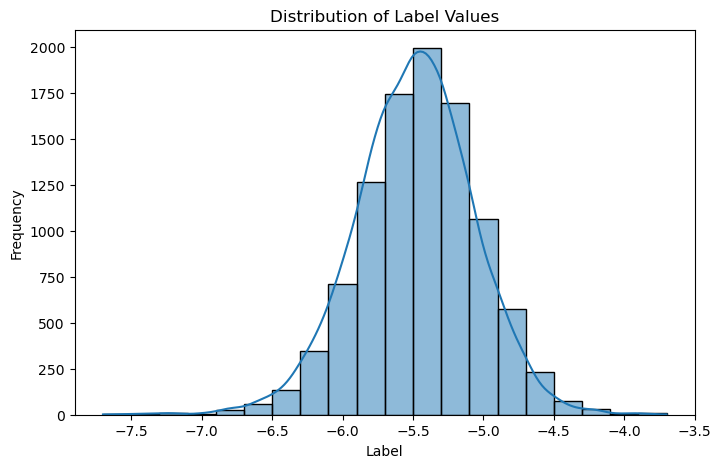

In [5]:
# ----------------------------------------------------------------------------
# Section 3: Analyze label distribution
# ----------------------------------------------------------------------------
print("Label Distribution Summary:")  # Print header
desc = df['label'].describe()        # Compute basic statistics
print(desc)                          # Print full describe output
# Explicitly print min, max, std
print(f"Minimum: {desc['min']:.4f}") # Print minimum value
print(f"Maximum: {desc['max']:.4f}") # Print maximum value
print(f"Standard Deviation: {desc['std']:.4f}")  # Print standard deviation
plt.figure(figsize=(8, 5))           # Set figure size for plot
sns.histplot(df['label'], kde=True, bins=20)  # Create histogram with KDE
plt.title('Distribution of Label Values')  # Set plot title
plt.xlabel('Label')                  # Set x-axis label
plt.ylabel('Frequency')              # Set y-axis label
plt.show()                           # Display the plot

In [8]:
# ----------------------------------------------------------------------------
# Section 4: Compute RDKit descriptors, handle NaNs, and filter features
# ----------------------------------------------------------------------------
# Compute initial descriptors
descriptors = []                     # List to hold descriptor values for all molecules
desc_names = [desc[0] for desc in Descriptors._descList]  # Get list of all RDKit descriptor names
for smi in df['SMILES']:             # Loop over each SMILES string in the DataFrame
    mol = Chem.MolFromSmiles(smi)    # Convert SMILES to RDKit molecule object
    if mol is None:                  # If conversion fails (invalid SMILES)
        descriptors.append([np.nan] * len(desc_names))  # Append NaNs for all descriptors
        continue                     # Skip to next
    desc_values = [desc[1](mol) for desc in Descriptors._descList]  # Compute all descriptors
    descriptors.append(desc_values)  # Append computed values to list
desc_df = pd.DataFrame(descriptors, columns=desc_names)  # Create DataFrame from list

# Save original descriptors (before any filtering)
desc_df_original = desc_df.copy()    # Copy for saving/exporting later
desc_df_original.to_csv('desc_df_original.csv', index=False)  # Save to CSV

In [9]:
desc_df_original.head()

,MaxEStateIndex,MinEStateIndex,MaxAbsEStateIndex,MinAbsEStateIndex,qed,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,13.213502,-1.010236,13.213502,0.029481,0.557798,243.194,233.114,243.065534,92,0,...,0,0,0,0,0,0,0,0,0,0
1,11.625685,-0.488343,11.625685,0.162613,0.606489,241.247,226.127,241.106256,94,0,...,0,0,0,0,0,0,0,0,0,0
2,10.706467,-1.181065,10.706467,0.172593,0.415739,205.210,190.090,205.095023,82,0,...,0,0,0,0,0,0,0,0,0,0
3,8.853217,-0.609120,8.853217,0.148378,0.595031,239.235,226.131,239.101839,92,0,...,0,0,0,0,0,0,0,0,0,0
4,11.566241,-0.638704,11.566241,0.193941,0.588358,242.231,228.119,242.090272,94,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
# Handle NaNs: Remove rows (compounds) with any NaN descriptors
nan_per_column = desc_df.isna().sum()  # NaNs per column
nan_cols = nan_per_column[nan_per_column > 0]  # Columns with NaNs
print(f"Descriptors (columns) with NaNs and their counts:\n{nan_cols}")

nan_per_row = desc_df.isna().sum(axis=1)  # NaNs per row
nan_rows_idx = nan_per_row[nan_per_row > 0].index  # Indices of rows with any NaN
print(f"Compounds (rows) with NaN descriptors and their indices:\n{nan_rows_idx}")
print(f"Number of compounds to drop: {len(nan_rows_idx)} ({100 * len(nan_rows_idx) / len(desc_df):.2f}% of total)")

# Drop these rows from df and desc_df
df = df.drop(index=nan_rows_idx).reset_index(drop=True)  # Clean main DataFrame
desc_df = desc_df.drop(index=nan_rows_idx).reset_index(drop=True)  # Clean descriptors
print(f"After NaN row removal - data shape: {df.shape}, descriptors shape: {desc_df.shape}")

# Save descriptors after NaN row removal
#desc_df_after_nan = desc_df.copy()   # Copy for saving/exporting
#desc_df_after_nan.to_csv('desc_df_after_nan.csv', index=False)  # Save to CSV

Descriptors (columns) with NaNs and their counts:
MaxPartialCharge       269
MinPartialCharge       269
MaxAbsPartialCharge    269
MinAbsPartialCharge    269
BCUT2D_MWHI            269
BCUT2D_MWLOW           269
BCUT2D_CHGHI           269
BCUT2D_CHGLO           269
BCUT2D_LOGPHI          269
BCUT2D_LOGPLOW         269
BCUT2D_MRHI            269
BCUT2D_MRLOW           269
dtype: int64
Compounds (rows) with NaN descriptors and their indices:
Index([  7861,   7873,  14475,  14476,  14595,  14596,  14597,  14645,  14646,
        14665,
       ...
       755171, 755172, 755173, 755366, 755367, 762063, 779425, 780052, 780064,
       780148],
      dtype='int64', length=269)
Number of compounds to drop: 269 (0.03% of total)
After NaN row removal - data shape: (781179, 4), descriptors shape: (781179, 208)


In [11]:
# Filter features: Remove low-variance and highly correlated descriptors
# Adapted from provided function: variance_threshold removes low-variance features;
# correlation_threshold removes features with high pairwise correlation (addresses multicollinearity)
variance_threshold = 0.01            # Minimum variance a feature must have to be kept (default 0.01)
correlation_threshold = 0.8          # Maximum absolute correlation allowed between two features (default 0.8)

from sklearn.feature_selection import VarianceThreshold  

# Apply variance threshold
selector = VarianceThreshold(threshold=variance_threshold)  # Initialize selector
desc_array = selector.fit_transform(desc_df)  # Fit and transform numerical features
selected_columns = desc_df.columns[selector.get_support()].tolist()  # Get selected column names
desc_df = pd.DataFrame(              # Rebuild DataFrame with selected features
    desc_array,
    index=desc_df.index,
    columns=selected_columns
)

# Remove highly correlated features
corr_matrix = desc_df.corr().abs()   # Compute absolute correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))  # Upper triangle
to_drop = [column for column in upper.columns if any(upper[column] > correlation_threshold)]  # Columns to drop
desc_df = desc_df.drop(columns=to_drop)  # Drop highly correlated columns

print(f"After filtering - descriptors shape: {desc_df.shape}")  # Print new shape

# Save filtered descriptors
desc_df_filtered = desc_df.copy()    # Copy for saving/exporting
desc_df_filtered.to_csv('desc_df_filtered.csv', index=False)  # Save to CSV

After filtering - descriptors shape: (781179, 117)


In [12]:
out_df = df.copy()                   # Copy all original columns to output DataFrame
out_df = pd.concat([out_df, desc_df], axis=1)  # Add descriptor columns to output
out_df.to_csv('df_all_with_filtered_rdkit_features.csv', index=False)

In [13]:
out_df.head(10)

,number,SMILES,Name,label,MaxEStateIndex,MinEStateIndex,MinAbsEStateIndex,qed,MolWt,FpDensityMorgan1,...,fr_piperzine,fr_priamide,fr_pyridine,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_unbrch_alkane,fr_urea
0,1,N=c1nc2n(cc1F)[C@H]1O[C@H](CO)[C@@H](O)[C@H]1O2,ZINC000000001477,-6.1,13.213502,-1.010236,0.029481,0.557798,243.194,1.588235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,Cc1cn([C@H]2C[C@@H](CO)N(O)C2)c(=O)[nH]c1=O,ZINC000000004266,-5.9,11.625685,-0.488343,0.162613,0.606489,241.247,1.529412,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,CC(=O)N[C@@H]1C[C@@H](O)[C@H](CO)O[C@@H]1O,ZINC000000005637,-5.0,10.706467,-1.181065,0.172593,0.415739,205.210,1.571429,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,Nc1ncc2c(ncn2COC(CO)CO)n1,ZINC000000005980,-5.3,8.853217,-0.609120,0.148378,0.595031,239.235,1.352941,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,Cc1cn([C@H]2O[C@@H](CO)[C@@H]2CO)c(=O)[nH]c1=O,ZINC000000006018,-5.7,11.566241,-0.638704,0.193941,0.588358,242.231,1.411765,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,6,Nc1ccn([C@H]2CO[C@@H](CO)[C@H](O)C2)c(=O)n1,ZINC000000006044,-6.2,11.582301,-0.788701,0.163668,0.581413,241.247,1.647059,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,7,CC(C)NC(=O)c1c(CO)no[n+]1[O-],ZINC000000006184,-5.6,11.373704,-0.610833,0.024537,0.606540,201.182,1.785714,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,8,CNc1nc(N(C)CO)nc(N(C)CO)n1,ZINC000000007465,-5.3,8.980617,-0.198961,0.198961,0.534117,228.256,1.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,9,OC[C@@H](O)Cc1cnc([C@@H](O)[C@H](O)CO)cn1,ZINC000000007502,-5.3,9.506096,-1.307239,0.133137,0.382602,244.247,1.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,10,Cc1cn([C@@H]2C[C@@H](O)[C@H](CO)O2)c(=O)c[n+]1...,ZINC000000008065,-6.2,11.598926,-0.808530,0.215718,0.482022,242.231,1.705882,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
out_df.tail()

,number,SMILES,Name,label,MaxEStateIndex,MinEStateIndex,MinAbsEStateIndex,qed,MolWt,FpDensityMorgan1,...,fr_piperzine,fr_priamide,fr_pyridine,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_unbrch_alkane,fr_urea
781174,782193,COC[C@@H]1[C@H](NC(CO)CO)[C@@H]2CCO[C@H]12,ZINC000218404185,NaN,9.066176,-0.230642,0.036760,0.545618,231.292,1.437500,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
781175,782194,CN(C)CCO[C@@H]1COCC[C@H]1NC(=O)CO,ZINC000218743468,NaN,11.141895,-0.484350,0.064294,0.617836,246.307,1.588235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
781176,782195,Cn1cc(S(=O)(=O)F)c(=O)n(C)c1=O,ZINC000238857165,NaN,12.517260,-5.088310,0.520301,0.555618,222.197,1.285714,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
781177,782196,O=C1NC(=O)[C@@H](CCS(=O)(=O)F)N1,ZINC000307689379,NaN,11.994428,-4.583802,0.253565,0.455746,210.186,1.384615,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
781178,782197,O=C1NC(=O)[C@H](CCS(=O)(=O)F)N1,ZINC000307689380,NaN,11.994428,-4.583802,0.253565,0.455746,210.186,1.384615,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## Model Training and Predictions

- You can run this part independently, after running Section 1 (import libraries).

In [2]:
df_all = pd.read_csv('df_all_with_filtered_rdkit_features.csv')

In [3]:
df = df_all

In [4]:
df_all.head()

,number,SMILES,Name,label,MaxEStateIndex,MinEStateIndex,MinAbsEStateIndex,qed,MolWt,FpDensityMorgan1,...,fr_piperzine,fr_priamide,fr_pyridine,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_unbrch_alkane,fr_urea
0,1,N=c1nc2n(cc1F)[C@H]1O[C@H](CO)[C@@H](O)[C@H]1O2,ZINC000000001477,-6.1,13.213502,-1.010236,0.029481,0.557798,243.194,1.588235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,Cc1cn([C@H]2C[C@@H](CO)N(O)C2)c(=O)[nH]c1=O,ZINC000000004266,-5.9,11.625685,-0.488343,0.162613,0.606489,241.247,1.529412,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,CC(=O)N[C@@H]1C[C@@H](O)[C@H](CO)O[C@@H]1O,ZINC000000005637,-5.0,10.706467,-1.181065,0.172593,0.415739,205.210,1.571429,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,Nc1ncc2c(ncn2COC(CO)CO)n1,ZINC000000005980,-5.3,8.853217,-0.609120,0.148378,0.595031,239.235,1.352941,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,Cc1cn([C@H]2O[C@@H](CO)[C@@H]2CO)c(=O)[nH]c1=O,ZINC000000006018,-5.7,11.566241,-0.638704,0.193941,0.588358,242.231,1.411765,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
df_all.shape

(781179, 121)

In [6]:
# Removing duplicates

# 1.  Compute the mean label for every SMILES (handles duplicates)
mean_label = (
    df.groupby('SMILES', as_index=False)['label']  # group by SMILES
      .mean()                                      # average label
      .set_index('SMILES')['label']                # Series: index = SMILES, value = mean label
)


# 2.  Drop duplicate SMILES but KEEP FIRST ROW to preserve original order & features
df_dedup = df.drop_duplicates(subset='SMILES', keep='first').reset_index(drop=True)


# 3.  Replace the kept rows’ label with the mean from step-1
df_dedup['label'] = df_dedup['SMILES'].map(mean_label)


# 4.  Move ‘label’ to be the 4-th column (index position 3)
label_col = df_dedup.pop('label')      # remove
df_dedup.insert(3, 'label', label_col) # re-insert at index 3

print(f"Deduplicated DataFrame shape: {df_dedup.shape}")

# (Optional) save
# df_dedup.to_csv('deduplicated_dataset.csv', index=False)


# 5.  Build desc_df by dropping the first 4 columns (metadata + label)
desc_df = df_dedup.iloc[:, 4:].copy()  # only numerical descriptor columns remain
print(f"desc_df shape: {desc_df.shape}")


Deduplicated DataFrame shape: (776427, 121)
desc_df shape: (776427, 117)


In [7]:
desc_df.head()

,MaxEStateIndex,MinEStateIndex,MinAbsEStateIndex,qed,MolWt,FpDensityMorgan1,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,...,fr_piperzine,fr_priamide,fr_pyridine,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_unbrch_alkane,fr_urea
0,13.213502,-1.010236,0.029481,0.557798,243.194,1.588235,19.142206,10.132514,2.505182,-2.136804,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,11.625685,-0.488343,0.162613,0.606489,241.247,1.529412,16.502492,10.153728,2.318689,-2.128119,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,10.706467,-1.181065,0.172593,0.415739,205.210,1.571429,16.624561,10.006924,2.355840,-2.357681,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,8.853217,-0.609120,0.148378,0.595031,239.235,1.352941,16.516978,10.402126,2.085244,-2.124338,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,11.566241,-0.638704,0.193941,0.588358,242.231,1.411765,16.550218,9.951202,2.428104,-2.429558,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [27]:
df.shape

(9989, 121)

In [28]:
# Handle NaNs in target 'label' column

nan_y_count = df['label'].isna().sum()  # Count NaNs in 'label'
print(f"Number of NaNs in target 'label': {nan_y_count}")

if nan_y_count > 0:
    nan_y_idx = df[df['label'].isna()].index  # Indices of rows with NaN in label
    print(f"Indices of rows with NaN in label: {nan_y_idx}")
    print(f"Percentage of rows to drop due to NaN in label: {100 * nan_y_count / len(df):.2f}%")
    
    # Drop rows with NaN in label (align with any prior row drops)
    df = df.dropna(subset=['label']).reset_index(drop=True)
    print(f"After dropping NaN in label - data shape: {df.shape}")
    
    # If you've already computed desc_df, drop corresponding rows (adjust indices if needed)
    desc_df = desc_df_all.drop(index=nan_y_idx).reset_index(drop=True)  # Sync with df

Number of NaNs in target 'label': 0


In [29]:
desc_df.shape

(9989, 117)

In [30]:
# ----------------------------------------------------------------------------
# Section 5: Prepare features and target
# ----------------------------------------------------------------------------
X = desc_df.values                   # Extract feature matrix as numpy array
y = df['label'].values               # Extract target labels as numpy array

# ----------------------------------------------------------------------------
# Section 6: Standardize features
# ----------------------------------------------------------------------------
scaler = StandardScaler()            # Initialize StandardScaler for zero mean and unit variance
X_scaled = scaler.fit_transform(X)   # Fit scaler to features and transform them


In [31]:
X.shape

(9989, 117)

In [32]:
y.shape

(9989,)

In [33]:
nan_per_column = desc_df.isna().sum()  # NaNs per column
nan_cols = nan_per_column[nan_per_column > 0]  # Columns with NaNs
print(f"Descriptors (columns) with NaNs and their counts:\n{nan_cols}")

Descriptors (columns) with NaNs and their counts:
Series([], dtype: int64)


This is the part it gets different from classification part.

In [34]:
# ----------------------------------------------------------------------------
# Section 7: Stratified train-test split (bin continuous y)
# ----------------------------------------------------------------------------
# Bin the continuous y into 5 bins for stratification (adjust n_bins as needed)
kbins = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')  # Initialize discretizer
y_binned = kbins.fit_transform(y.reshape(-1, 1)).flatten()  # Bin y values into discrete categories

# Perform stratified train-test split using binned y
X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X_scaled, y, df.index, test_size=0.2, random_state=42, stratify=y_binned
)  # Split with stratification on binned y

c:\Users\ASUS\miniconda3\envs\qsar\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [35]:
# ----------------------------------------------------------------------------
# Section 8: Define models, perform grid search with CV, and select/save best model
# ----------------------------------------------------------------------------
# Dictionary of models and their parameter grids
models = {                           # Models dictionary
    'RandomForest': (RandomForestRegressor(random_state=42),  # RF model
                     {'n_estimators': [50, 100], 'max_depth': [5, 10]}),  # Brief grid
    'SVR': (SVR(), {'C': [1, 10], 'kernel': ['rbf', 'linear']})  # SVR model and grid
}

results = {}                         # To store results
kf = KFold(n_splits=5, shuffle=True, random_state=42)  # 5-fold CV

best_global_model = None             # To hold the overall best model
best_global_score = -np.inf          # Track best R2 score
best_global_name = None              # Name of best model

for name, (model, param_grid) in models.items():  # Loop over models
    grid = GridSearchCV(model, param_grid, cv=kf, scoring='r2', n_jobs=-1)  # Grid search with R2 scoring
    grid.fit(X_train, y_train)       # Fit on train
    best_model = grid.best_estimator_  # Get best model for this type
    y_pred = best_model.predict(X_test)  # Predict on test
    
    # Compute metrics
    mse = mean_squared_error(y_test, y_pred)  
    mae = mean_absolute_error(y_test, y_pred)  
    r2 = r2_score(y_test, y_pred)   
    
    results[name] = {                # Store results
        'best_params': grid.best_params_,  # Best hyperparameters
        'mse': mse,                  # MSE
        'mae': mae,                  # MAE
        'r2': r2,                    # R2
        'y_test': y_test,            # True values
        'y_pred': y_pred,            # Predictions
        'best_model': best_model     # Save the best model for this type (no clone needed if not modifying)
    }
    print(f"{name} Metrics: MSE={mse:.4f}, MAE={mae:.4f}, R2={r2:.4f}")
    
    # Update global best if this model's test R2 is higher
    if r2 > best_global_score:
        best_global_score = r2
        best_global_model = best_model
        best_global_name = name

print(f"\nBest overall model: {best_global_name} with params {results[best_global_name]['best_params']} and test R2={best_global_score:.4f}")

RandomForest Metrics: MSE=0.0569, MAE=0.1861, R2=0.6889
SVR Metrics: MSE=0.0558, MAE=0.1864, R2=0.6947

Best overall model: SVR with params {'C': 1, 'kernel': 'linear'} and test R2=0.6947


In [41]:
# ----------------------------------------------------------------------------
# Section 8 (Rewritten): Efficient model sweep with stratified CV on binned y
# ----------------------------------------------------------------------------
import time  # timing runs
import numpy as np  # numeric ops
from scipy.stats import spearmanr  # rank metric

# CV and search utilities
from sklearn.model_selection import StratifiedKFold, GridSearchCV  # stratified CV and search
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler  # binning and scaling
from sklearn.pipeline import Pipeline  # pipelines
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  # metrics

# Models
from sklearn.ensemble import HistGradientBoostingRegressor, ExtraTreesRegressor, RandomForestRegressor  # tree ensembles
from sklearn.linear_model import ElasticNet, Ridge  # linear baselines
from sklearn.svm import LinearSVR  # fast linear SVR

# ------------------------------
# A) Build stratified CV on binned target (for stability)
# ------------------------------
# Bin continuous y into quantiles to preserve label distribution in each fold
n_bins = 10  # 10 quantile bins is a good default for ~10k samples
kb = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')  # quantile bins
y_bins = kb.fit_transform(y_train.reshape(-1, 1)).ravel().astype(int)  # fit on train labels only (fix: no .values if ndarray)

# StratifiedKFold using the binned labels
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # 5-fold stratified
cv_splitter = list(cv.split(X_train, y_bins))  # materialize splits for reuse

# ------------------------------
# B) Define models and compact grids (time-budgeted)
# ------------------------------
models = {
    # Tree ensembles (no scaling)
    'HGBR': (
        HistGradientBoostingRegressor(random_state=42, early_stopping=True),  # fast boosting
        {
            'max_leaf_nodes': [31, 63, 127],  # tree size
            'max_depth': [None],              # let leaf nodes control complexity
            'learning_rate': [0.05, 0.1],     # learning rate
            'min_samples_leaf': [10, 20],     # regularization
            'max_bins': [255],                # default, stable
        }
    ),
    'ExtraTrees': (
        ExtraTreesRegressor(random_state=42, n_jobs=-1),  # very randomized trees
        {
            'n_estimators': [200, 400],      # enough trees but time-bounded
            'max_depth': [None, 12],         # limit depth for speed/generalization
            'max_features': ['sqrt', 0.5],   # feature subsampling
            'min_samples_leaf': [1, 3],      # regularization
        }
    ),
    'RandomForest': (
        RandomForestRegressor(random_state=42, n_jobs=-1),  # classic baseline
        {
            'n_estimators': [200, 400],      # similar budget to ExtraTrees
            'max_depth': [None, 12],         # depth control
            'max_features': ['sqrt', 0.5],   # feature subsampling
            'min_samples_leaf': [1, 3],      # regularization
        }
    ),

    # Linear baselines (with scaling)
    'ElasticNet': (
        Pipeline([
            ('scaler', StandardScaler(with_mean=True, with_std=True)),  # standardize features
            ('model', ElasticNet(random_state=42, max_iter=5000))        # elastic net
        ]),
        {
            'model__alpha': [0.01, 0.03, 0.1, 0.3, 1.0],  # overall regularization
            'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],  # balance L1/L2
        }
    ),
    'Ridge': (
        Pipeline([
            ('scaler', StandardScaler(with_mean=True, with_std=True)),  # standardize features
            ('model', Ridge(random_state=42))                           # L2 baseline
        ]),
        {
            'model__alpha': [0.1, 1.0, 3.0, 10.0, 30.0],  # L2 strength
        }
    ),

    # Fast margin baseline (linear SVR; avoid RBF cost at ~10k samples)
    'LinearSVR': (
        Pipeline([
            ('scaler', StandardScaler(with_mean=True, with_std=True)),  # standardize features
            ('model', LinearSVR(random_state=42, max_iter=10000))       # linear SVR
        ]),
        {
            'model__C': [0.3, 1.0, 3.0, 10.0],  # margin penalty
            'model__epsilon': [0.0, 0.05, 0.1], # insensitive zone
        }
    ),
}

# ------------------------------
# C) Grid search with stratified CV and evaluation
# ------------------------------
results = {}  # store outcomes
best_global = {'name': None, 'score': -np.inf, 'est': None}  # track best by R2
start_all = time.time()  # total timer

for name, (est, grid) in models.items():
    print(f"\n=== {name} ===")  # model header

    # Choose scoring; optimize R2 but we will also compute MAE and Spearman
    gs = GridSearchCV(
        estimator=est,              # estimator or pipeline
        param_grid=grid,            # compact grid
        cv=cv_splitter,             # stratified splits on binned y
        scoring='r2',               # primary objective
        n_jobs=-1,                  # parallelize where supported
        verbose=0,                  # quiet output
        refit=True,                 # refit best on full train
        return_train_score=False    # keep light
    )

    t0 = time.time()  # model timer
    gs.fit(X_train, y_train)  # fit search
    fit_time = time.time() - t0  # elapsed

    best_model = gs.best_estimator_  # best estimator
    y_pred = best_model.predict(X_test)  # test predictions

    # Metrics
    mse = mean_squared_error(y_test, y_pred)  # MSE
    mae = mean_absolute_error(y_test, y_pred)  # MAE
    r2 = r2_score(y_test, y_pred)  # R2
    sp, _ = spearmanr(y_test, y_pred)  # Spearman rank correlation

    # Store
    results[name] = {
        'best_params': gs.best_params_,
        'mse': mse,
        'mae': mae,
        'r2': r2,
        'spearman': sp,
        'fit_time_sec': fit_time,
        'best_model': best_model,
        'y_test': y_test,
        'y_pred': y_pred,
    }

    # Report concise metrics
    print(f"Best params: {gs.best_params_}")
    print(f"Test: R2={r2:.4f} | MAE={mae:.4f} | MSE={mse:.4f} | Spearman={sp:.4f} | time={fit_time:.1f}s")

    # Track best by R2
    if r2 > best_global['score']:
        best_global = {'name': name, 'score': r2, 'est': best_model}

total_time = time.time() - start_all  # total elapsed
print(f"\nBest overall: {best_global['name']} with R2={best_global['score']:.4f}")
print(f"Total sweep time: {total_time/60:.1f} minutes")

# Access the best model
best_model = best_global['est']  # trained, ready to save/use

c:\Users\ASUS\miniconda3\envs\qsar\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(



=== HGBR ===
Best params: {'learning_rate': 0.1, 'max_bins': 255, 'max_depth': None, 'max_leaf_nodes': 31, 'min_samples_leaf': 20}
Test: R2=0.7210 | MAE=0.1784 | MSE=0.0510 | Spearman=0.8292 | time=35.2s

=== ExtraTrees ===
Best params: {'max_depth': 12, 'max_features': 0.5, 'min_samples_leaf': 3, 'n_estimators': 400}
Test: R2=0.7036 | MAE=0.1821 | MSE=0.0542 | Spearman=0.8235 | time=62.2s

=== RandomForest ===
Best params: {'max_depth': 12, 'max_features': 0.5, 'min_samples_leaf': 3, 'n_estimators': 400}
Test: R2=0.7049 | MAE=0.1820 | MSE=0.0540 | Spearman=0.8229 | time=132.6s

=== ElasticNet ===
Best params: {'model__alpha': 0.01, 'model__l1_ratio': 0.1}
Test: R2=0.6822 | MAE=0.1906 | MSE=0.0581 | Spearman=0.8028 | time=1.8s

=== Ridge ===
Best params: {'model__alpha': 0.1}
Test: R2=0.6952 | MAE=0.1862 | MSE=0.0557 | Spearman=0.8098 | time=0.3s

=== LinearSVR ===
Best params: {'model__C': 1.0, 'model__epsilon': 0.05}
Test: R2=0.6938 | MAE=0.1868 | MSE=0.0560 | Spearman=0.8082 | time

c:\Users\ASUS\miniconda3\envs\qsar\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


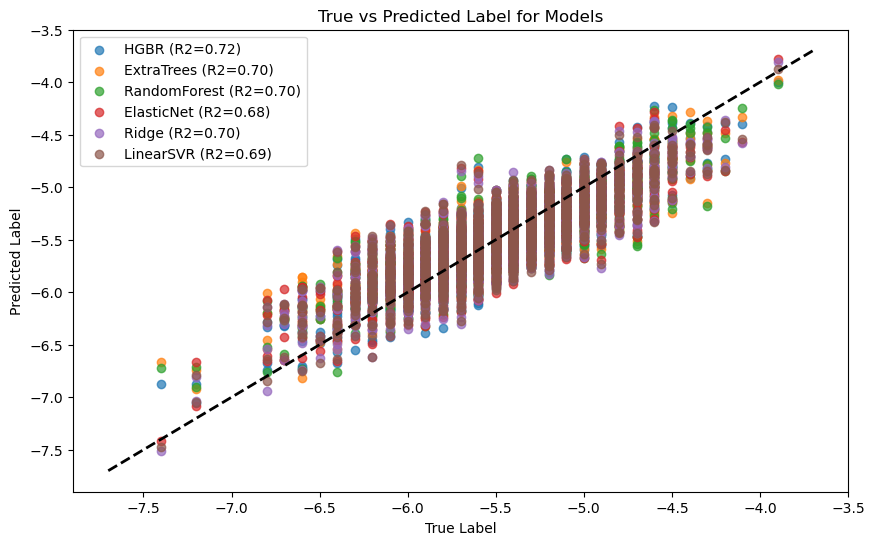


Model Comparison Metrics (on Test Set):
          Model       MSE       MAE        R2
0          HGBR  0.051017  0.178392  0.721029
1    ExtraTrees  0.054211  0.182126  0.703567
2  RandomForest  0.053963  0.182049  0.704921
3    ElasticNet  0.058127  0.190567  0.682153
4         Ridge  0.055749  0.186215  0.695153
5     LinearSVR  0.056006  0.186808  0.693751


In [42]:
# ----------------------------------------------------------------------------
# Section 9: Compare models with figures and metrics table
# ----------------------------------------------------------------------------

plt.figure(figsize=(10, 6))          # Set figure size for scatter plot
for name, res in results.items():    # Loop over results
    plt.scatter(res['y_test'], res['y_pred'], label=f'{name} (R2={res["r2"]:.2f})', alpha=0.7)  # Scatter plot of true vs predicted
plt.plot([min(y), max(y)], [min(y), max(y)], 'k--', lw=2)  # Add diagonal reference line
plt.xlabel('True Label')             # Set x-axis label
plt.ylabel('Predicted Label')        # Set y-axis label
plt.title('True vs Predicted Label for Models')  # Set plot title
plt.legend()                         # Add legend
plt.show()                           # Display the plot

# Additional model comparison: Print metrics table
print("\nModel Comparison Metrics (on Test Set):")  # Print header
metrics_df = pd.DataFrame({          # Create DataFrame for metrics
    'Model': list(results.keys()),   # Model names
    'MSE': [res['mse'] for res in results.values()],  # MSE values
    'MAE': [res['mae'] for res in results.values()],  # MAE values
    'R2': [res['r2'] for res in results.values()]     # R2 values
})
print(metrics_df)                    # Print the metrics DataFrame


In [ ]:
# ----------------------------------------------------------------------------
# Section 10: Predict labels for the full dataset (even the labeled and duplicated data) using the best model
# ----------------------------------------------------------------------------

# Standardize using the same scaler from training (Section 6)
full_X_scaled = scaler.transform(desc_df_all)  # Transform with trained scaler

# Predict using the best global model
predictions = best_global_model.predict(full_X_scaled)  # Generate predictions

# Add 'Predicted Affinity' column to df_all
df_all.insert(4, 'Predicted Affinity', predictions)  # Insert column

# Save the updated df_all
df_all.to_csv('df_all_with_predictions.csv', index=False)  # Export to CSV

print("Predictions completed and added to df_all as 'Predicted Affinity' column.")


c:\Users\ASUS\miniconda3\envs\qsar\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [2]:
df_full = pd.read_csv('df_all_with_predictions.csv')

In [3]:
df_full.head()

,number,SMILES,Name,label,Predicted Affinity,MaxEStateIndex,MinEStateIndex,MinAbsEStateIndex,qed,MolWt,...,fr_piperzine,fr_priamide,fr_pyridine,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_unbrch_alkane,fr_urea
0,1,N=c1nc2n(cc1F)[C@H]1O[C@H](CO)[C@@H](O)[C@H]1O2,ZINC000000001477,-6.1,-5.980616,13.213502,-1.010236,0.029481,0.557798,243.194,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,Cc1cn([C@H]2C[C@@H](CO)N(O)C2)c(=O)[nH]c1=O,ZINC000000004266,-5.9,-5.900323,11.625685,-0.488343,0.162613,0.606489,241.247,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,CC(=O)N[C@@H]1C[C@@H](O)[C@H](CO)O[C@@H]1O,ZINC000000005637,-5.0,-5.252120,10.706467,-1.181065,0.172593,0.415739,205.210,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,Nc1ncc2c(ncn2COC(CO)CO)n1,ZINC000000005980,-5.3,-5.561441,8.853217,-0.609120,0.148378,0.595031,239.235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,Cc1cn([C@H]2O[C@@H](CO)[C@@H]2CO)c(=O)[nH]c1=O,ZINC000000006018,-5.7,-5.701878,11.566241,-0.638704,0.193941,0.588358,242.231,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Final Results

In [38]:
# ----------------------------------------------------------------------------
# Section 11: Display the final results
# ----------------------------------------------------------------------------

# Load the dataset with predictions
df_full = pd.read_csv('df_all_with_predictions.csv')

# Check for required columns
required_cols = ['number', 'Name', 'SMILES', 'label', 'Predicted Affinity']

# Sort by 'Predicted Affinity' in descending order to get highest affinities first
df_sorted = df_full.sort_values(by='Predicted Affinity')

# Select the top 20 compounds
top20 = df_sorted.head(20).copy()

# Add a 'number' column with ranks 1 to 20
top20.insert(0, 'Rank', range(1, 21))

# Select and display the table with specified columns
table = top20[['Rank', 'number', 'Name', 'SMILES', 'label', 'Predicted Affinity']]
print(table)

# Save the table to CSV
table.to_csv('top20_highest_affinity_compounds.csv', index=False)


        Rank  number              Name  \
696509     1  697062  ZINC000225188545   
110495     2  110875  ZINC000223722063   
56746      3   56916  ZINC000195801523   
56745      4   56915  ZINC000195801521   
56747      5   56917  ZINC000195801525   
56744      6   56914  ZINC000195801520   
110498     7  110878  ZINC000223725920   
76151      8   76463  ZINC000209001129   
25147      9   25265  ZINC000115808131   
89089     10   89416  ZINC000214529666   
95        11      96  ZINC000001295289   
686715    12  687170  ZINC000220663541   
686714    13  687169  ZINC000220663485   
686716    14  687171  ZINC000220663598   
686717    15  687172  ZINC000220663656   
88130     16   88457  ZINC000214239522   
9435      17    9445  ZINC000039368901   
34897     18   35026  ZINC000142151449   
37797     19   37933  ZINC000143770374   
48595     20   48758  ZINC000150052438   

                                                  SMILES  label  \
696509                           O=C(ON1NNNNN1)ON1